In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("restaurant_sales_data.csv")

df.head()

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.set_index("date", inplace=True)

df.head()

,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
date,,,,,,,,,,,,
2024-01-01,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
2024-01-01,42,Fine Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.64,56.82,143,False,False,Sunny
2024-01-01,5,Cafe,Mushroom Soup,Dinner,"mushrooms, cream, onion, garlic, vegetable broth",3.5,12.68,19.43,73,False,True,Cloudy
2024-01-01,27,Food Stall,Tandoori Chicken,Dinner,"chicken, yogurt, tandoori masala, ginger, garlic",7.0,15.68,14.60,410,True,False,Cloudy
2024-01-01,28,Fine Dining,Nasi Lemak,Breakfast,"rice, coconut milk, sambal, anchovies, egg, pe...",2.5,11.92,16.75,315,False,False,Sunny


In [6]:
for lag in [1,2,3,7,14,21,28]:
    df[f"lag_{lag}"] = df["quantity_sold"].shift(lag)

for window in [3,7,14,30]:
    df[f"rolling_mean_{window}"] = (
        df["quantity_sold"]
        .shift(1)
        .rolling(window)
        .mean()
    )

for window in [7,14]:
    df[f"rolling_std_{window}"] = (
        df["quantity_sold"]
        .shift(1)
        .rolling(window)
        .std()
    )

df["day"] = df.index.day
df["month"] = df.index.month
df["week"] = df.index.isocalendar().week.astype(int)
df["quarter"] = df.index.quarter
df["year"] = df.index.year
df["dayofweek"] = df.index.dayofweek
df["is_weekend"] = (df.index.dayofweek>=5).astype(int)

df.dropna(inplace=True)

In [7]:
X = df.drop("quantity_sold", axis=1)

y = df["quantity_sold"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(9970, 60)


In [8]:
train_size = int(len(df)*0.85)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [9]:
model = joblib.load("restaurant_demand_model.pkl")

model_features = joblib.load("model_features.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [10]:
X_test = X_test.reindex(
    columns=model_features,
    fill_value=0
)

print(X_test.shape)

(1496, 97)


In [11]:
prediction = model.predict(X_test)

results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": prediction

})

results.head()

,Actual,Predicted
0,180,188.542969
1,674,227.496613
2,61,127.467361
3,44,115.554626
4,177,138.158966


In [12]:
mae = mean_absolute_error(
    y_test,
    prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)

r2 = r2_score(
    y_test,
    prediction
)

print("="*50)

print(f"MAE : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

print("="*50)

MAE : 158.07
RMSE : 228.73
R² Score : -0.0340


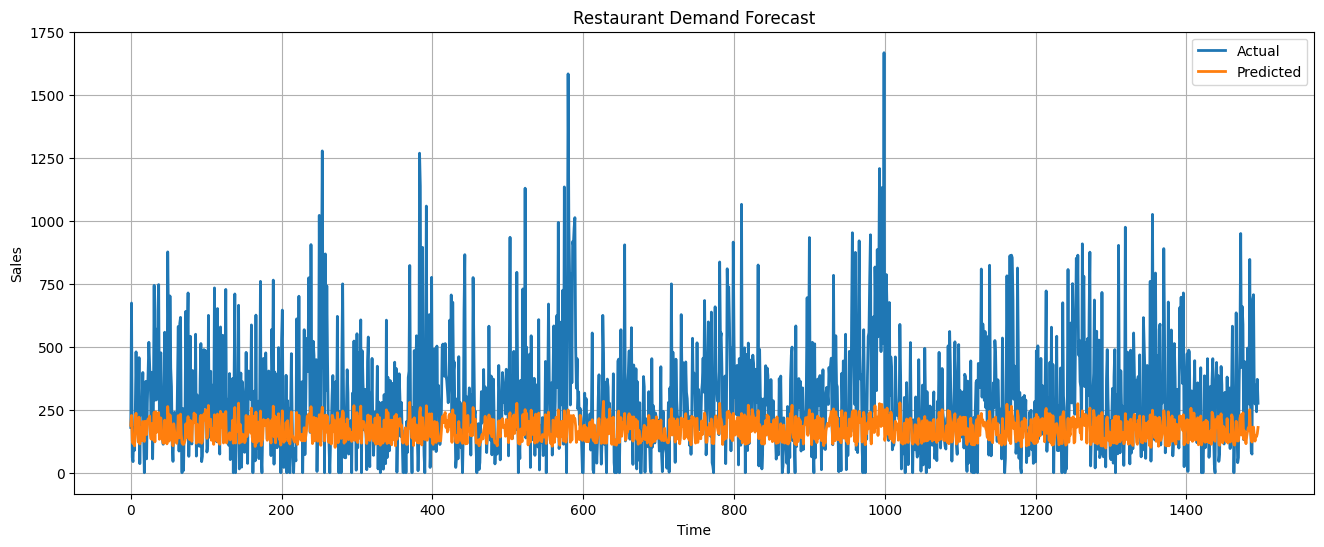

In [13]:
plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    prediction,
    label="Predicted",
    linewidth=2
)

plt.title("Restaurant Demand Forecast")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature": model_features,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
82,"key_ingredients_tags_black tea, condensed milk...",0.137124
1,typical_ingredient_cost,0.110477
3,actual_selling_price,0.088505
79,menu_item_name_Teh Tarik,0.083220
4,has_promotion,0.075227
72,menu_item_name_Kaya Toast Set,0.056773
67,menu_item_name_Cendol,0.049596
94,"key_ingredients_tags_white bread, kaya, butter...",0.044394
92,"key_ingredients_tags_rice, coconut milk, samba...",0.032728
80,meal_type_Dinner,0.031400


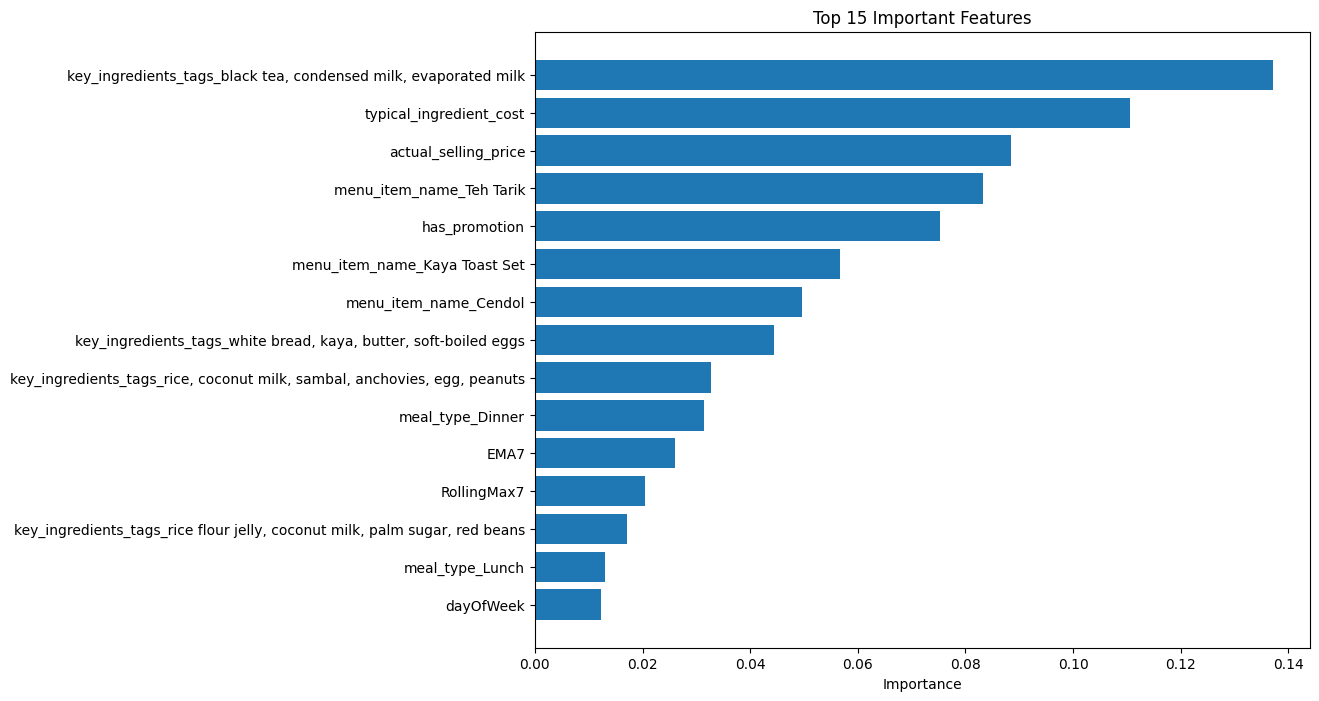

In [15]:
top = importance.head(15)

plt.figure(figsize=(10,8))

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

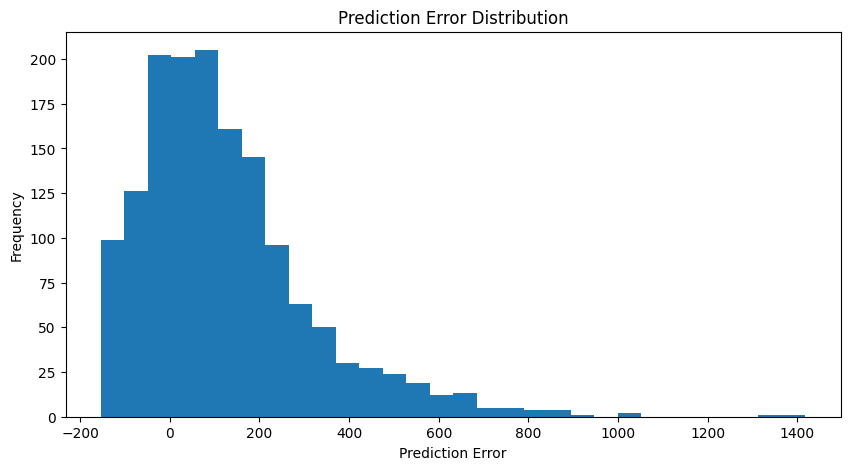

In [16]:
errors = y_test.values - prediction

plt.figure(figsize=(10,5))

plt.hist(

    errors,

    bins=30

)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

In [17]:
report = pd.DataFrame({

    "Metric":[

        "MAE",

        "RMSE",

        "R² Score"

    ],

    "Value":[

        mae,

        rmse,

        r2

    ]

})

report

,Metric,Value
0,MAE,158.070602
1,RMSE,228.731727
2,R² Score,-0.033960


In [18]:
results.to_csv(

    "Demand_Forecast_Results.csv",

    index=False

)

print("Prediction file saved.")

Prediction file saved.


In [19]:
results.head(10)

,Actual,Predicted
0,180,188.542969
1,674,227.496613
2,61,127.467361
3,44,115.554626
4,177,138.158966
5,89,106.546028
6,237,219.916931
7,480,236.154297
8,272,161.574051
9,170,156.240189
